# GICS extractor via Gemini

Legge la chiave da `.env` (variabile `GEMINI_API_KEY`).


In [7]:
from __future__ import annotations

import json
import os
import time
from pathlib import Path
from typing import Any, Iterable

import pandas as pd
import torch

# Config
DATA_DIR = Path("../data/processed")
OUTPUT_CSV = Path("../results/gics_by_ticker.csv")
MODEL_NAME = "gemini-2.5-flash"
REQUEST_DELAY_SEC = 0.6  # rate limiting

ENV_PATH = Path("../.env")

# Set this to a specific file name (relative to DATA_DIR) to select a .pt file.
# Example: "corr_windows_tensor_data_00_20_w724_s10.pt"
PT_FILENAME = "corr_windows_tensor_data_00_20_w724_s10.pt"

def load_env(path: Path) -> None:
    if not path.exists():
        return
    for raw_line in path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        os.environ.setdefault(key, value)

load_env(ENV_PATH)

api_key = os.getenv("GEMINI_API_KEY")
if not api_key:
    raise RuntimeError("Missing GEMINI_API_KEY in .env or environment.")

if not PT_FILENAME:
    raise ValueError("Set PT_FILENAME to a .pt file in data/processed before running.")

PT_PATH = DATA_DIR / PT_FILENAME
if not PT_PATH.exists():
    raise FileNotFoundError(f"PT file not found: {PT_PATH}")

PT_PATH

WindowsPath('../data/processed/corr_windows_tensor_data_00_20_w724_s10.pt')

In [8]:
def _flatten(items: Iterable[Any]) -> list[Any]:
    out: list[Any] = []
    for item in items:
        if isinstance(item, (list, tuple, set)):
            out.extend(_flatten(item))
        else:
            out.append(item)
    return out


def extract_tickers(obj: Any) -> list[str]:
    if isinstance(obj, pd.DataFrame):
        return [str(c) for c in obj.columns]
    if isinstance(obj, dict):
        for key in ("tickers", "symbols", "columns", "assets"):
            if key in obj:
                return [str(x) for x in _flatten(obj[key])]
        # Heuristic: find first list of strings
        for value in obj.values():
            if isinstance(value, (list, tuple)) and value and all(
                isinstance(x, (str, bytes)) for x in value
            ):
                return [x.decode() if isinstance(x, bytes) else str(x) for x in value]
    if isinstance(obj, (list, tuple)) and obj and all(
        isinstance(x, (str, bytes)) for x in obj
    ):
        return [x.decode() if isinstance(x, bytes) else str(x) for x in obj]
    if hasattr(obj, "tickers"):
        return [str(x) for x in getattr(obj, "tickers")]
    raise ValueError("Could not extract tickers from the .pt file")

loaded = torch.load(PT_PATH, map_location="cpu")

# Many .pt files store a dict; this keeps behavior robust.
tickers = extract_tickers(loaded)

# Normalize tickers
seen: set[str] = set()
normalized = []
for t in tickers:
    t = t.strip().upper()
    if t and t not in seen:
        seen.add(t)
        normalized.append(t)

tickers = normalized
len(tickers), tickers[:10]

(362,
 ['AAPL', 'ABC', 'ABMD', 'ABT', 'ADBE', 'ADI', 'ADM', 'ADP', 'ADSK', 'AEE'])

In [11]:
from google import genai
import os
import random
print(f"Chiave API trovata: {os.environ.get('GEMINI_API_KEY') is not None}")

# Il client legge automaticamente la chiave dalla variabile d'ambiente GEMINI_API_KEY
client = genai.Client()

# Retry/backoff config
MAX_RETRIES = 5
BACKOFF_BASE_SEC = 1.0
BACKOFF_MAX_SEC = 30.0
RANDOM_DELAY_MIN_SEC = 2.0
RANDOM_DELAY_MAX_SEC = 5.0

prompt_template = (
    "Sei un analista finanziario esperto. Il tuo compito e' classificare il ticker azionario "
    "che riceverai in una delle 11 categorie GICS (Global Industry Classification Standard) corrette.\n\n"
    "Queste sono le uniche 11 categorie valide:\n"
    "1. Energy\n"
    "2. Materials\n"
    "3. Industrials\n"
    "4. Consumer Discretionary\n"
    "5. Consumer Staples\n"
    "6. Health Care\n"
    "7. Financials\n"
    "8. Information Technology\n"
    "9. Communication Services\n"
    "10. Utilities\n"
    "11. Real Estate\n\n"
    "Regole:\n"
    "1. Rispondi ESCLUSIVAMENTE con il nome della categoria.\n"
    "2. Non aggiungere spiegazioni, punteggiatura extra o testo introduttivo.\n"
    "3. Se il ticker non e' valido o non e' riconosciuto, rispondi solo \"Unknown\".\n\n"
    "Esempi:\n"
    "Ticker da classificare: AAPL\n"
    "Risposta: Information Technology\n\n"
    "Ticker da classificare: XOM\n"
    "Risposta: Energy\n\n"
    "Ticker da classificare: JPM\n"
    "Risposta: Financials\n\n"
    "Ticker da classificare: KO\n"
    "Risposta: Consumer Staples\n\n"
    "Ticker da classificare: ABCD\n"
    "Risposta: Unknown\n\n"
    "Ticker da classificare: {ticker}"
)


def _sleep_backoff(attempt: int) -> None:
    delay = min(BACKOFF_MAX_SEC, BACKOFF_BASE_SEC * (2 ** attempt))
    time.sleep(delay)


def _sleep_between_calls() -> None:
    time.sleep(random.uniform(RANDOM_DELAY_MIN_SEC, RANDOM_DELAY_MAX_SEC))


def fetch_gics(ticker: str) -> dict[str, Any]:
    last_error: Exception | None = None
    for attempt in range(MAX_RETRIES):
        try:
            response = client.models.generate_content(
                model=MODEL_NAME,
                contents=prompt_template.format(ticker=ticker),
            )
            category = response.text.strip()
            return {"ticker": ticker, "gics_category": category}
        except Exception as exc:
            last_error = exc
            print(f"{ticker} -> RETRY {attempt + 1}/{MAX_RETRIES}: {exc}")
            _sleep_backoff(attempt)
    raise last_error if last_error else RuntimeError("Unknown error")

# Resume if the output already exists.
if OUTPUT_CSV.exists():
    existing = pd.read_csv(OUTPUT_CSV)
    done = set(existing["ticker"].astype(str).str.upper())
else:
    existing = pd.DataFrame()
    done = set()

rows = []
total = len(tickers)
processed = 0
for idx, ticker in enumerate(tickers, start=1):
    if ticker in done:
        continue
    print(f"Progress {idx}/{total} - {ticker}")
    try:
        row = fetch_gics(ticker)
        print(f"{ticker} -> {row['gics_category']}")
    except Exception as exc:
        row = {
            "ticker": ticker,
            "gics_category": "",
            "error": str(exc),
        }
        print(f"{ticker} -> ERROR: {exc}")
    rows.append(row)
    processed += 1
    _sleep_between_calls()

new_df = pd.DataFrame(rows)
if not existing.empty:
    out_df = pd.concat([existing, new_df], ignore_index=True)
else:
    out_df = new_df

out_df.to_csv(OUTPUT_CSV, index=False)
OUTPUT_CSV

Chiave API trovata: True
Progress 1/362 - AAPL
AAPL -> RETRY 1/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
AAPL -> Information Technology
Progress 2/362 - ABC
ABC -> Unknown
Progress 3/362 - ABMD
ABMD -> Health Care
Progress 4/362 - ABT
ABT -> RETRY 1/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
ABT -> RETRY 2/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
ABT -> RETRY 3/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later

WindowsPath('../results/gics_by_ticker.csv')

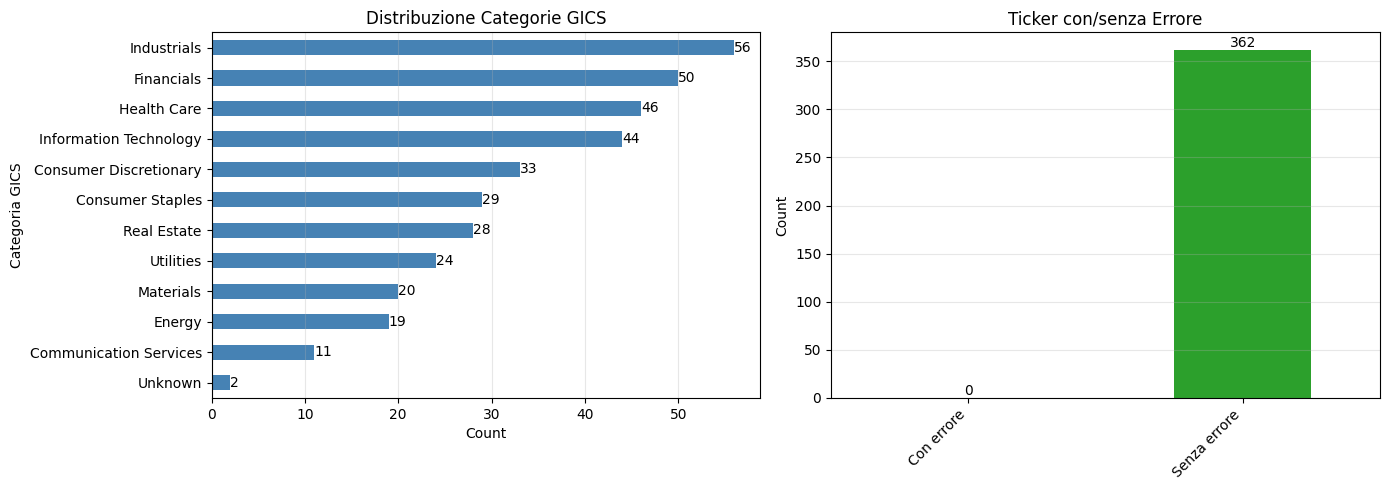


Risultati:
Total tickers: 362
Con errore: 0
Senza errore: 362

Categorie:
gics_category
Unknown                    2
Communication Services    11
Energy                    19
Materials                 20
Utilities                 24
Real Estate               28
Consumer Staples          29
Consumer Discretionary    33
Information Technology    44
Health Care               46
Financials                50
Industrials               56


In [17]:
import matplotlib.pyplot as plt

# Leggi il CSV
results_df = pd.read_csv(OUTPUT_CSV)

# Istogramma categorie GICS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grafico 1: Distribuzione categorie
categories = results_df['gics_category'].value_counts().sort_values(ascending=True)
categories.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Categoria GICS')
axes[0].set_title('Distribuzione Categorie GICS')
axes[0].grid(axis='x', alpha=0.3)
axes[0].bar_label(axes[0].containers[0], label_type='edge')

# Grafico 2: Ticker con errore
error_counts = results_df['error'].notna().sum()
no_error_counts = results_df['error'].isna().sum()
error_data = pd.Series({'Con errore': error_counts, 'Senza errore': no_error_counts})
error_data.plot(kind='bar', ax=axes[1], color=['#d62728', '#2ca02c'])
axes[1].set_ylabel('Count')
axes[1].set_title('Ticker con/senza Errore')
axes[1].set_xticklabels(error_data.index, rotation=45, ha='right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].bar_label(axes[1].containers[0])

plt.tight_layout()
plt.show()

print(f"\nRisultati:")
print(f"Total tickers: {len(results_df)}")
print(f"Con errore: {error_counts}")
print(f"Senza errore: {no_error_counts}")
print(f"\nCategorie:")
print(categories.to_string())

In [16]:
# Retry dei ticker con errore
results_with_errors = results_df[results_df['error'].notna()].copy()
print(f"Trovati {len(results_with_errors)} ticker con errore:")
print(results_with_errors['ticker'].tolist())

rows_retry = []
for idx, row in results_with_errors.iterrows():
    ticker = row['ticker']
    print(f"\nRetrying {ticker}...")
    try:
        result = fetch_gics(ticker)
        result['error'] = None  # Pulisci l'errore precedente
        print(f"{ticker} -> {result['gics_category']}")
    except Exception as exc:
        result = {
            "ticker": ticker,
            "gics_category": "",
            "error": str(exc),
        }
        print(f"{ticker} -> ERROR: {exc}")
    rows_retry.append(result)
    _sleep_between_calls()

# Aggiorna il dataframe: rimuovi i vecchi record con errore e aggiungi i nuovi
results_df = results_df[results_df['error'].isna()].copy()
retry_df = pd.DataFrame(rows_retry)
results_df = pd.concat([results_df, retry_df], ignore_index=True)

# Salva il CSV aggiornato
results_df.to_csv(OUTPUT_CSV, index=False)
print(f"\n✓ CSV aggiornato: {OUTPUT_CSV}")
print(f"Tickers con errore residuo: {results_df['error'].notna().sum()}")

Trovati 20 ticker con errore:
['ABT', 'ALXN', 'AMZN', 'CLX', 'COST', 'CPRT', 'CTSH', 'GE', 'GLW', 'LEG', 'LH', 'MCK', 'MOS', 'NKE', 'ODFL', 'PAYX', 'PFE', 'PKI', 'PVH', 'PXD']

Retrying ABT...
ABT -> Health Care

Retrying ALXN...
ALXN -> Health Care

Retrying AMZN...
AMZN -> Consumer Discretionary

Retrying CLX...
CLX -> Consumer Staples

Retrying COST...
COST -> Consumer Staples

Retrying CPRT...
CPRT -> RETRY 1/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
CPRT -> RETRY 2/5: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
CPRT -> Industrials

Retrying CTSH...
CTSH -> Information Technology

Retrying GE...
GE -> Industrials

Retrying GLW...
GLW -> RETRY 1/5: 503 UNAVAILABLE. {'error': {'code